In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
annual_all = pd.read_parquet("data/annual_distribution_mickey.parquet")
quarterly_all = pd.read_parquet("data/quarterly_distribution_mickey.parquet")
monthly_all = pd.read_parquet("data/monthly_distribution_mickey.parquet")

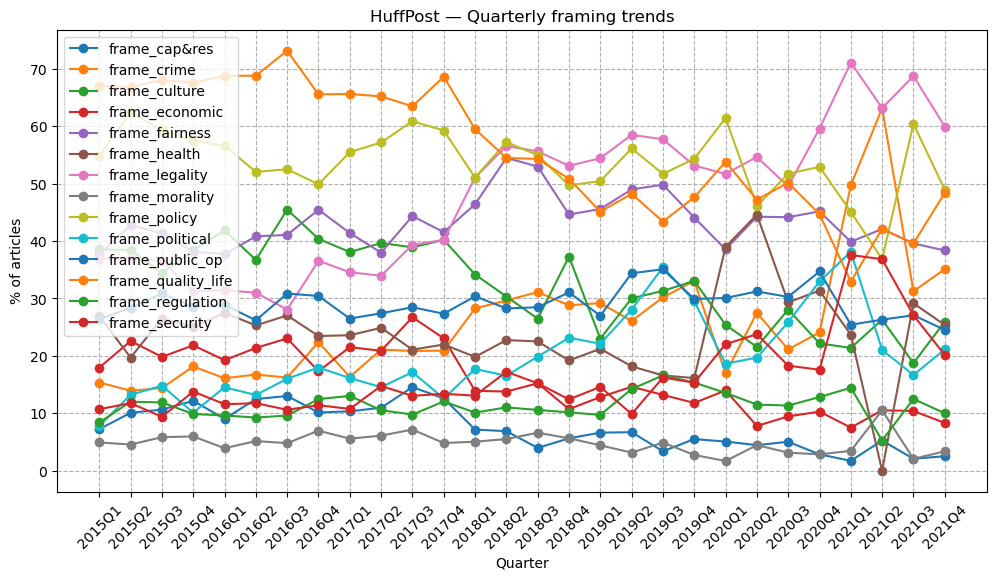

In [3]:
# Multi line plot with one outlet over time
outlet = "HuffPost"

quarterly = quarterly_all.loc[outlet]

plt.figure(figsize=(12,6))
for frame in quarterly.columns:
    plt.plot(quarterly.index, quarterly[frame], label=frame, marker="o")

plt.title(f"{outlet} — Quarterly framing trends")
plt.ylabel("% of articles")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

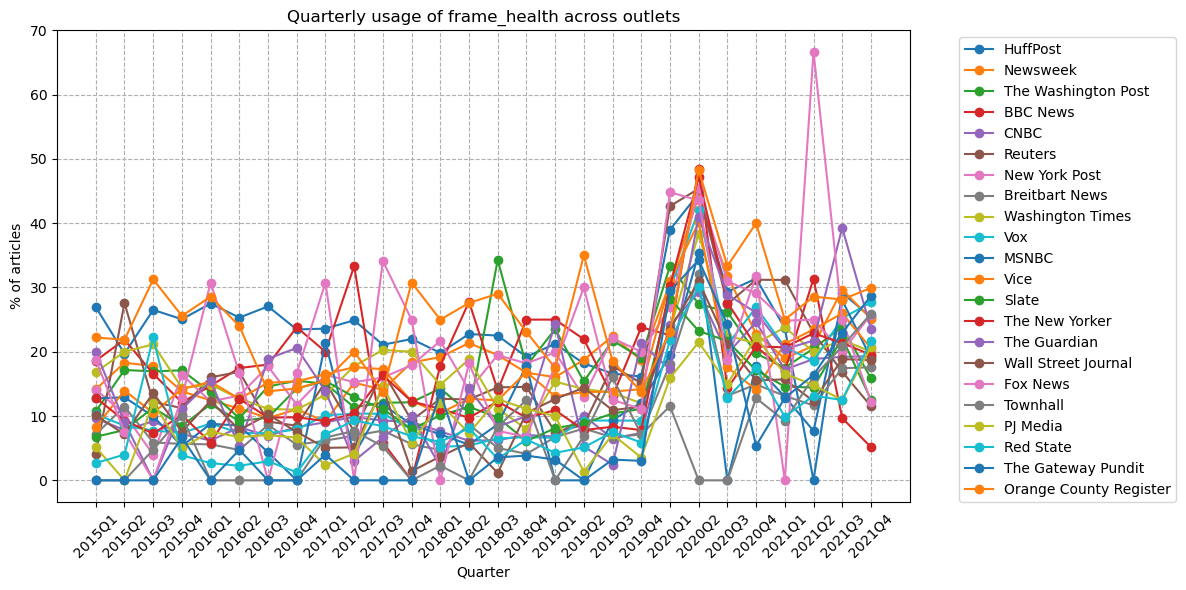

In [4]:
# Multi line plot with one frame over time
frame = "frame_health"

plt.figure(figsize=(12,6))
for outlet in quarterly_all.index.get_level_values(0).unique():
    quarterly = quarterly_all.loc[outlet]
    plt.plot(quarterly.index,quarterly[frame],label=outlet,marker="o")

plt.title(f"Quarterly usage of {frame} across outlets")
plt.ylabel("% of articles")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

In [5]:
# Melt to long format and compute biggest change each quarter
quarterly_long = (quarterly_all.reset_index().melt(id_vars=["outlet", "quarter"],var_name="frame",value_name="pct"))


quarterly_long["delta_q"] = (quarterly_long.groupby(["outlet", "frame"])["pct"].diff())

In [6]:
# Show biggest changes per outlet
outlet = "HuffPost"

big_moves = (quarterly_long[quarterly_long["outlet"] == outlet].dropna(subset=["delta_q"]).sort_values("delta_q", ascending=False))

big_moves

,outlet,quarter,frame,pct,delta_q
3106,HuffPost,2021Q3,frame_health,29.166667,29.166667
640,HuffPost,2021Q1,frame_crime,49.710983,25.622235
4954,HuffPost,2021Q3,frame_policy,60.416667,23.574561
3100,HuffPost,2020Q1,frame_health,38.983051,22.841319
8032,HuffPost,2021Q1,frame_security,37.572254,19.981129
...,...,...,...,...,...
4949,HuffPost,2020Q2,frame_policy,46.096654,-15.344024
636,HuffPost,2020Q1,frame_crime,16.949153,-16.121714
5569,HuffPost,2021Q2,frame_political,21.052632,-17.097657
3105,HuffPost,2021Q2,frame_health,0.000000,-23.699422


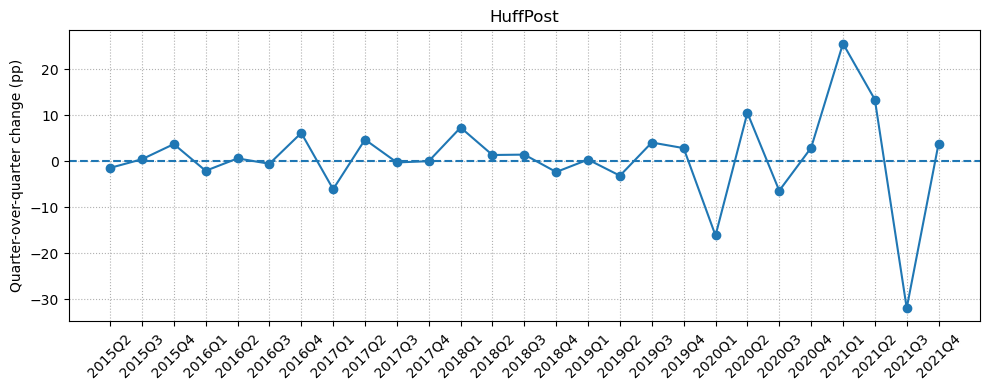

In [12]:
#Visualize framing shift for single frame/outlet

outlet = "HuffPost"
frame = "frame_crime"

subset = quarterly_long[(quarterly_long["outlet"] == outlet) & (quarterly_long["frame"] == frame)].dropna(subset=["delta_q"])

plt.figure(figsize=(10,4))
plt.plot(subset["quarter"], subset["delta_q"], marker="o")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.ylabel("Quarter-over-quarter change (pp)")
plt.title(f"{outlet}")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


In [8]:
# Compute mean/standard deviation across outlets for each quarter/frame
stats = (quarterly_long.groupby(["quarter", "frame"])["delta_q"].agg(mean_delta="mean", std_delta="std").reset_index())

# merge back
q_with_stats = quarterly_long.merge(stats,on=["quarter", "frame"],how="left")

# z-score of how unusual each outlet's change is
q_with_stats["delta_z"] = ((q_with_stats["delta_q"] - q_with_stats["mean_delta"]) / q_with_stats["std_delta"])

In [9]:
# Comapre events wehere an outlets shift in frame is unusally large compared to peers (Z score over 2)

big_outlier_moves = q_with_stats[q_with_stats["delta_z"].abs() >= 2].sort_values("delta_z", ascending=False)

big_outlier_moves

,outlet,quarter,frame,pct,delta_q,mean_delta,std_delta,delta_z
4809,Townhall,2020Q2,frame_morality,100.000000,96.153846,6.012319,20.251807,4.451036
4766,Fox News,2016Q3,frame_morality,66.666667,50.000000,4.260219,10.760848,4.250574
498,Townhall,2020Q3,frame_cap&res,50.000000,50.000000,-0.336113,12.012533,4.190300
1113,Townhall,2020Q2,frame_crime,100.000000,69.230769,3.745654,15.913883,4.114968
5847,MSNBC,2020Q4,frame_political,60.000000,60.000000,6.904786,13.158344,4.035099
...,...,...,...,...,...,...,...,...
73,The Washington Post,2019Q2,frame_cap&res,7.692308,-15.837104,-0.743566,3.802210,-3.969675
499,Townhall,2020Q4,frame_cap&res,4.069767,-45.930233,-1.728443,10.911016,-4.051116
6657,Townhall,2020Q2,frame_public_op,0.000000,-80.769231,-5.590616,17.575370,-4.277498
4767,Fox News,2016Q4,frame_morality,0.000000,-66.666667,-3.171941,14.486629,-4.382988


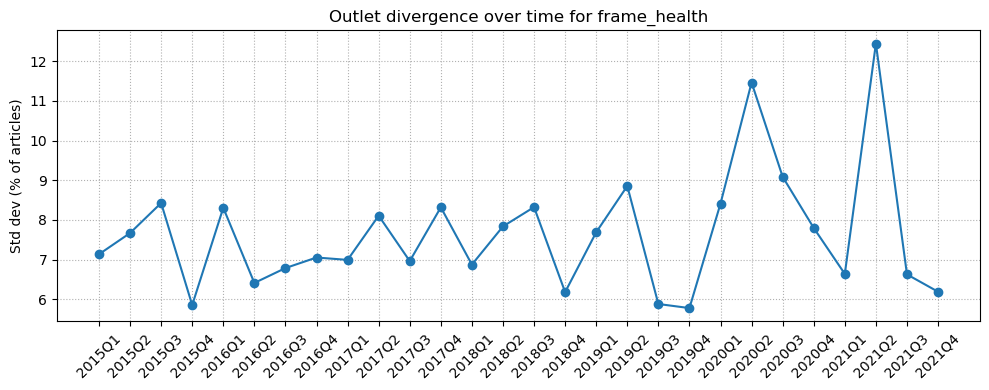

In [11]:
# Compate how much divergence at each event

# std of each frame across outlets per quarter
divergence = (quarterly_all.groupby("quarter")[quarterly_all.columns].std())

frame = "frame_health"

plt.figure(figsize=(10,4))
plt.plot(divergence.index, divergence[frame], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Std dev (% of articles)")
plt.title(f"Outlet divergence over time for {frame}")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

In [13]:
# Which frames are consistantly the most divisive across outlets?
frame_polarization = divergence.mean().sort_values(ascending=False)
frame_polarization

frame_quality_life    21.998848
frame_political       18.454455
frame_economic        18.244759
frame_legality        17.868503
frame_policy          16.879413
frame_fairness        16.869788
frame_culture         16.392567
frame_crime           16.306578
frame_public_op       13.794222
frame_cap&res         11.187785
frame_security        11.039702
frame_regulation       9.967014
frame_health           7.648132
frame_morality         4.579516
dtype: float64